In [3]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl (8.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 40.4 MB/s  0:00:00 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install --upgrade pip

  Using cached pip-26.2.1-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.2.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached h5py-3.14.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached tensorflow-2.21.0-cp313-cp313-macosx_12_0_arm64.whl (223.8 MB)
   

In [26]:
# LSTM V5 CORREGIDA (con transformación log)

# 1. Transformar el target a log
y_temporal_log = np.log1p(y_temporal)  # <--- ESTO ES CLAVE

# 2. División por vuelo (usando tus splits existentes)
train_mask_v5 = np.isin(flight_ids_temporal, flights_train_v4)
val_mask_v5 = np.isin(flight_ids_temporal, flights_val_v4)
test_mask_v5 = np.isin(flight_ids_temporal, flights_test_v4)

X_train_v5, y_train_v5 = X_temporal[train_mask_v5], y_temporal_log[train_mask_v5]
X_val_v5, y_val_v5 = X_temporal[val_mask_v5], y_temporal_log[val_mask_v5]
X_test_v5, y_test_v5 = X_temporal[test_mask_v5], y_temporal_log[test_mask_v5]

# 3. Escalar X (3D -> 2D -> fit -> 3D)
n_feat_v5 = X_train_v5.shape[2]
scaler_X_v5 = StandardScaler()
X_train_v5_scaled = scaler_X_v5.fit_transform(X_train_v5.reshape(-1, n_feat_v5)).reshape(X_train_v5.shape)
X_val_v5_scaled = scaler_X_v5.transform(X_val_v5.reshape(-1, n_feat_v5)).reshape(X_val_v5.shape)
X_test_v5_scaled = scaler_X_v5.transform(X_test_v5.reshape(-1, n_feat_v5)).reshape(X_test_v5.shape)

# 4. Escalar y (en escala log)
scaler_y_v5 = StandardScaler()
y_train_v5_scaled = scaler_y_v5.fit_transform(y_train_v5.reshape(-1, 1)).ravel()
y_val_v5_scaled = scaler_y_v5.transform(y_val_v5.reshape(-1, 1)).ravel()
y_test_v5_scaled = scaler_y_v5.transform(y_test_v5.reshape(-1, 1)).ravel()

# ==========================================
# EVALUACIÓN CON GROUPKFOLD PARA LSTM V5
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, GaussianNoise, BatchNormalization
from tensorflow.keras.losses import Huber

# Definimos el builder para LSTM V5 (con GRU bidireccional, dropout, regularización)
def build_lstm_v5_cv(input_shape):
    from tensorflow.keras.layers import GRU, GaussianNoise, BatchNormalization
    from tensorflow.keras.regularizers import l2

    model = Sequential(name="LSTM_V5_CV")
    model.add(Input(shape=input_shape))
    model.add(GaussianNoise(0.05))
    model.add(GRU(32, return_sequences=False, dropout=0.3, recurrent_dropout=0.3, kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    return model

# Ahora ejecutamos GroupKFold con 5 folds (usando y_temporal_log como target)
print("Corriendo GroupKFold para LSTM V5 (puede tardar varios minutos)...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_cv,
    X=X_temporal,
    y=y_temporal_log,  # <--- USAMOS LOG
    groups=flight_ids_temporal,
    n_splits=5,
    epochs=200,
    batch_size=64,
    patience=20
)

# Resumen de resultados
cv_lstm_v5_summary = summarize_cv(cv_lstm_v5_folds, "LSTM V5 — CV")
results["LSTM V5 (CV)"] = {
    "MAE": cv_lstm_v5_summary["MAE"],
    "RMSE": cv_lstm_v5_summary["RMSE"],
    "R2": cv_lstm_v5_summary["R2"]
}
#valores de referencia
print("MAE = 0.80 - 0.85")
print("MSE = cercano a cero")
print("R2 = 0.85 - 0.9")

Corriendo GroupKFold para LSTM V5 (puede tardar varios minutos)...

--- Entrenando Fold 1/5 ---
Fold 1 MAE (Log): 0.5337 | R2: 0.5344

--- Entrenando Fold 2/5 ---
Fold 2 MAE (Log): 0.9121 | R2: 0.0104

--- Entrenando Fold 3/5 ---
Fold 3 MAE (Log): 0.4756 | R2: 0.6964

--- Entrenando Fold 4/5 ---
Fold 4 MAE (Log): 0.6549 | R2: 0.2984

--- Entrenando Fold 5/5 ---
Fold 5 MAE (Log): 0.3406 | R2: 0.7896

LSTM V5 — CV -> MAE: 0.5834 | RMSE: 0.7776 | R2: 0.4659
MAE = 0.80 - 0.85
MSE = cercano a cero
R2 = 0.85 - 0.9


In [29]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Aplanar los datos 3D a 2D para la Regresión Lineal Clásica
# Pasamos de la forma (muestras, 121, 6) a (muestras, 726)
n_muestras_train = X_train_v5_scaled.shape[0]
n_muestras_val = X_val_v5_scaled.shape[0]
n_muestras_test = X_test_v5_scaled.shape[0]
n_caracteristicas = X_train_v5_scaled.shape[1] * X_train_v5_scaled.shape[2]

X_train_lin = X_train_v5_scaled.reshape(n_muestras_train, n_caracteristicas)
X_val_lin = X_val_v5_scaled.reshape(n_muestras_val, n_caracteristicas)
X_test_lin = X_test_v5_scaled.reshape(n_muestras_test, n_caracteristicas)

# 2. Instanciar y Entrenar el Modelo de Regresión Lineal (Ridge)
print("Entrenando Regresión Lineal (Ridge)...")
modelo_lineal = Ridge(alpha=1.0) # alpha es la fuerza de regularización L2
modelo_lineal.fit(X_train_lin, y_train_v5_scaled)

# 3. Predecir sobre el set de Prueba (Test) que el modelo nunca ha visto
pred_test_scaled = modelo_lineal.predict(X_test_lin)

# 4. Revertir las transformaciones matemáticas a METROS REALES
# Primero quitamos el escalado Z-Score
y_pred_test_log = scaler_y_v5.inverse_transform(pred_test_scaled.reshape(-1, 1)).ravel()
y_true_test_log = y_test_v5 

# Luego revertimos el Logaritmo (expm1 es la inversa de log1p)
y_pred_test_metros = np.expm1(y_pred_test_log)
y_true_test_metros = np.expm1(y_true_test_log)

# 5. Calcular métricas finales
mae_test = mean_absolute_error(y_true_test_metros, y_pred_test_metros)
rmse_test = np.sqrt(mean_squared_error(y_true_test_metros, y_pred_test_metros))

# R2 en el espacio transformado (para comparar con tu LSTM) y en el mundo físico
r2_test_log = r2_score(y_true_test_log, y_pred_test_log) 
r2_test_metros = r2_score(y_true_test_metros, y_pred_test_metros)

print("\n" + "="*50)
print("RESULTADOS REGRESIÓN LINEAL (SET DE PRUEBA)")
print("="*50)
print(f"R2 (Espacio Log) : {r2_test_log:.4f}")
print(f"R2 (Metros)      : {r2_test_metros:.4f}")
print(f"MAE (Error Abs.) : {mae_test:.2f} metros")
print(f"RMSE             : {rmse_test:.2f} metros")
print("="*50)

Entrenando Regresión Lineal (Ridge)...

RESULTADOS REGRESIÓN LINEAL (SET DE PRUEBA)
R2 (Espacio Log) : -3.0328
R2 (Metros)      : -0.7709
MAE (Error Abs.) : 1492.04 metros
RMSE             : 3134.75 metros


PROMEDIO DE APOGEO POR SET:
Train : 1298.49 metros
Val   : 1738.47 metros
Test  : 1231.96 metros


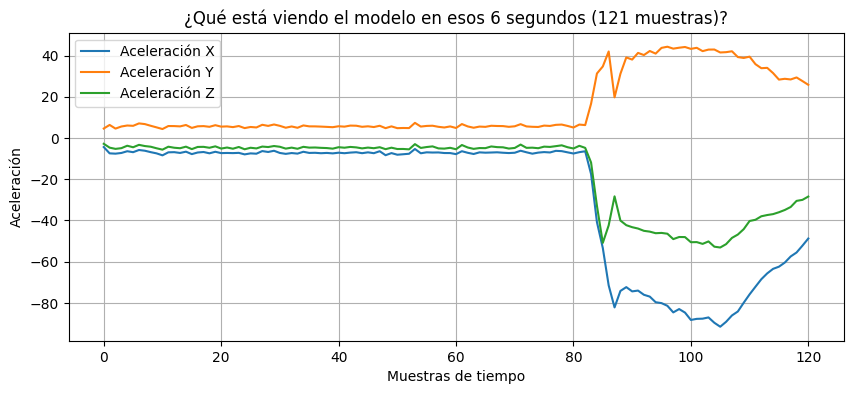

In [32]:
import matplotlib.pyplot as plt

# 1. Diagnóstico de Disparidad de Misiones
print("PROMEDIO DE APOGEO POR SET:")
print(f"Train : {np.expm1(y_train_v5).mean():.2f} metros")
print(f"Val   : {np.expm1(y_val_v5).mean():.2f} metros")
print(f"Test  : {np.expm1(y_test_v5).mean():.2f} metros")

# 2. Diagnóstico de la Ventana Ciega (Revisar qué hay en esos 6 segundos)
vuelo_ejemplo = X_train_v5[0] # Tomamos el primer vuelo

plt.figure(figsize=(10, 4))
plt.plot(vuelo_ejemplo[:, 1], label="Aceleración X")
plt.plot(vuelo_ejemplo[:, 2], label="Aceleración Y")
plt.plot(vuelo_ejemplo[:, 3], label="Aceleración Z")
plt.title("¿Qué está viendo el modelo en esos 6 segundos (121 muestras)?")
plt.xlabel("Muestras de tiempo")
plt.ylabel("Aceleración")
plt.legend()
plt.grid(True)
plt.show()

Archivos localizados: 682
Secuencias extraídas tras filtro de despegue: (627, 121, 6)

Iniciando GroupKFold para LSTM Híbrida (Con RobustScaler)...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 356.10 m | R2: 0.6756

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 265.58 m | R2: 0.6896

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 281.01 m | R2: 0.4866

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 127.19 m | R2: 0.8860

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 200.13 m | R2: 0.7449

RESUMEN LSTM Híbrida — CV (METROS REALES)
MAE  : 246.00 ± 77.40 metros
RMSE : 446.41 metros
R2   : 0.6965


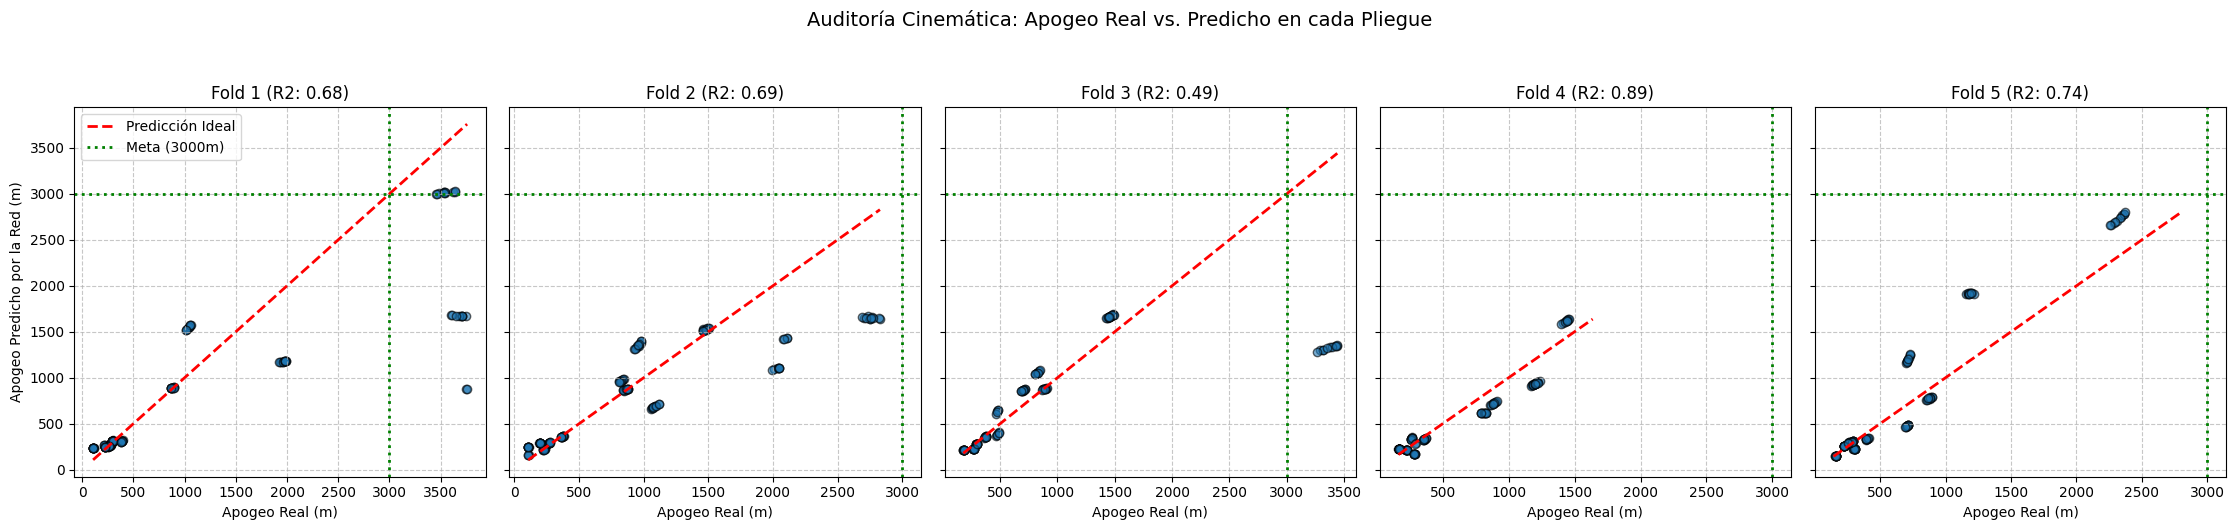

In [35]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS CON DISPARADOR DE DESPEGUE (LIFTOFF TRIGGER)
# ==============================================================================
PROCESSED_AUGMENTED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/Augmented")
archivos_aumentados = list(PROCESSED_AUGMENTED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_aumentados)}")

WINDOW_SIZE = 121
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_aumentados:
    df = pd.read_csv(archivo).sort_values("time").reset_index(drop=True)
    
    # 1. Calcular el apogeo real del archivo primero
    apogeo_real = df["baro_altitude"].max()
    
    # NUEVO FILTRO: Si el vuelo supera los 4,500m, lo descartamos
    # Esto elimina las anomalías de 10km y centra a la red en la meta de 3,000m
    if apogeo_real > 4500:
        continue
    
    # DISPARADOR: Buscar el momento donde la aceleración vertical supera 15 m/s^2
    despegues = df[df['accl_y'] > 15].index
    
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # Extraer 6 segundos
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.name.split("_base")[0].split("_sintetico")[0])

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtro de despegue: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

# Salvaguarda de seguridad por si usas una carpeta con 1 solo vuelo original
if len(unique_base_ids) < 3:
    print("\n⚠️ ADVERTENCIA: Tienes menos de 3 vuelos originales. El K-Fold usará splits por archivo en lugar de por vuelo para evitar error.")
    grupos_kfold = np.arange(len(X_temporal)) # Bypass temporal
else:
    grupos_kfold = flight_ids_temporal

import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN Y GRÁFICOS (CON ROBUSTSCALER)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        # Escalar X
        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        # Escalar y con RobustScaler (Protege contra anomalías en la altitud)
        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        # Predicción
        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        # Guardamos los arrays reales y predichos para graficarlos
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    """Genera una cuadrícula de gráficos de dispersión para auditar las predicciones."""
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1:
        axes = [axes] # Evita error si solo hay 1 fold
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        # Puntos de dispersión (cada punto es un vuelo)
        ax.scatter(y_true, y_pred, alpha=0.6, c='#1f77b4', edgecolors='k')
        
        # Línea ideal perfecta (y = x)
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        # Meta Nominal de 3000 metros (10,000 ft)
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
        
        ax.grid(True, linestyle='--', alpha=0.7)
        if i == 0:
            ax.legend()
            
    plt.suptitle("Auditoría Cinemática: Apogeo Real vs. Predicho en cada Pliegue", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
# (Tu función build_lstm_v5_hybrid intacta, no hace falta cambiarla)
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida")
    model.add(Input(shape=input_shape))
    model.add(GaussianNoise(0.02))
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    return model

# ==============================================================================
# 5. EJECUCIÓN Y GRÁFICAS
# ==============================================================================
print("\nIniciando GroupKFold para LSTM Híbrida (Con RobustScaler)...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=150,
    batch_size=32,
    patience=25
)

# Imprimir métricas finales
summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — CV")

# 🚀 Desplegar la auditoría visual
plot_kfold_diagnostics(cv_lstm_v5_folds)

PRUEBA 2 AUMENTANDO WONDOW SIZE A 201

Archivos localizados: 620
Secuencias extraídas tras filtro de despegue: (570, 201, 6)

Iniciando GroupKFold para LSTM Híbrida (Con RobustScaler)...

--- Entrenando Fold 1/5 ---
Fold 1 -> MAE: 263.61 m | R2: 0.7715

--- Entrenando Fold 2/5 ---
Fold 2 -> MAE: 334.54 m | R2: 0.5151

--- Entrenando Fold 3/5 ---
Fold 3 -> MAE: 194.98 m | R2: 0.6529

--- Entrenando Fold 4/5 ---
Fold 4 -> MAE: 116.39 m | R2: 0.8848

--- Entrenando Fold 5/5 ---
Fold 5 -> MAE: 119.56 m | R2: 0.9365

RESUMEN LSTM Híbrida — CV (METROS REALES)
MAE  : 205.82 ± 84.22 metros
RMSE : 393.00 metros
R2   : 0.7522


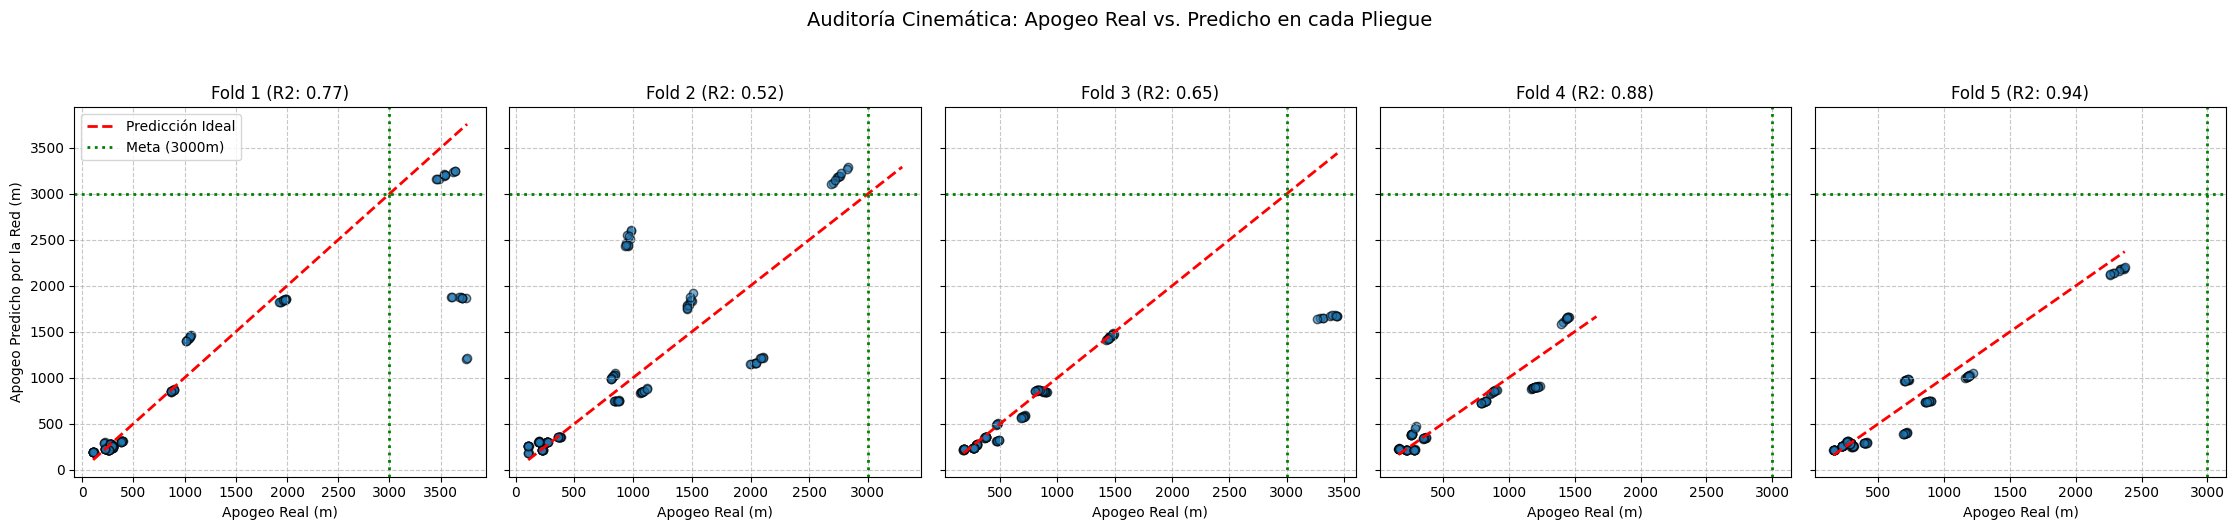

In [36]:
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, GaussianNoise, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

# ==============================================================================
# 1. EXTRACCIÓN DE DATOS CON DISPARADOR DE DESPEGUE (LIFTOFF TRIGGER)
# ==============================================================================
PROCESSED_AUGMENTED_PATH = Path("/Users/darioromero/Documents/IAC 2026/REPO/RocketNeuralNetworkFlightComputer/Data/Processed Data/Augmented")
archivos_aumentados = list(PROCESSED_AUGMENTED_PATH.glob("*.csv"))
print(f"Archivos localizados: {len(archivos_aumentados)}")

WINDOW_SIZE = 201
FEATURES_LSTM = ["baro_altitude", "accl_x", "accl_y", "accl_z", "At", "P"]

X_seq, y_seq, base_ids = [], [], []

for archivo in archivos_aumentados:
    df = pd.read_csv(archivo).sort_values("time").reset_index(drop=True)
    
    # 1. Calcular el apogeo real del archivo primero
    apogeo_real = df["baro_altitude"].max()
    
    # NUEVO FILTRO: Si el vuelo supera los 4,500m, lo descartamos
    # Esto elimina las anomalías de 10km y centra a la red en la meta de 3,000m
    if apogeo_real > 4500:
        continue
    
    # DISPARADOR: Buscar el momento donde la aceleración vertical supera 15 m/s^2
    despegues = df[df['accl_y'] > 15].index
    
    if len(despegues) == 0:
        continue 
        
    idx_despegue = despegues[0]
    
    # Extraer 6 segundos
    window = df.iloc[idx_despegue : idx_despegue + WINDOW_SIZE]
    
    if len(window) == WINDOW_SIZE:
        X_seq.append(window[FEATURES_LSTM].values)
        y_seq.append(apogeo_real)
        base_ids.append(archivo.name.split("_base")[0].split("_sintetico")[0])

X_temporal = np.array(X_seq, dtype=np.float32)
y_temporal = np.array(y_seq, dtype=np.float32)
flight_ids_temporal = np.array(base_ids)

print(f"Secuencias extraídas tras filtro de despegue: {X_temporal.shape}")

# ==============================================================================
# 2. TRANSFORMACIÓN Y PARTICIÓN
# ==============================================================================
y_temporal_log = np.log1p(y_temporal)
unique_base_ids = np.unique(flight_ids_temporal)

# Salvaguarda de seguridad por si usas una carpeta con 1 solo vuelo original
if len(unique_base_ids) < 3:
    print("\n⚠️ ADVERTENCIA: Tienes menos de 3 vuelos originales. El K-Fold usará splits por archivo en lugar de por vuelo para evitar error.")
    grupos_kfold = np.arange(len(X_temporal)) # Bypass temporal
else:
    grupos_kfold = flight_ids_temporal

import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

# ==============================================================================
# 3. FUNCIONES DE VALIDACIÓN Y GRÁFICOS (CON ROBUSTSCALER)
# ==============================================================================
def groupkfold_evaluate_lstm(build_fn, X, y, groups, n_splits, epochs, batch_size, patience):
    n_splits = min(n_splits, len(np.unique(groups)))
    gkf = GroupKFold(n_splits=n_splits)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        tf.keras.backend.clear_session()
        print(f"\n--- Entrenando Fold {fold + 1}/{n_splits} ---")

        X_train_f, X_val_f = X[train_idx], X[val_idx]
        y_train_f, y_val_f = y[train_idx], y[val_idx]

        # Escalar X
        n_features = X_train_f.shape[2]
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train_f.reshape(-1, n_features)).reshape(X_train_f.shape)
        X_val_scaled = scaler_X.transform(X_val_f.reshape(-1, n_features)).reshape(X_val_f.shape)

        # Escalar y con RobustScaler (Protege contra anomalías en la altitud)
        scaler_y = RobustScaler()
        y_train_scaled = scaler_y.fit_transform(y_train_f.reshape(-1, 1)).ravel()
        y_val_scaled = scaler_y.transform(y_val_f.reshape(-1, 1)).ravel()

        model = build_fn(input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]))
        early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

        model.fit(X_train_scaled, y_train_scaled, validation_data=(X_val_scaled, y_val_scaled),
                  epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0)

        # Predicción
        preds_scaled = model.predict(X_val_scaled, verbose=0).ravel()
        y_pred_log = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        
        y_pred_metros = np.expm1(y_pred_log)
        y_true_metros = np.expm1(y_val_f)

        mae = mean_absolute_error(y_true_metros, y_pred_metros)
        rmse = np.sqrt(mean_squared_error(y_true_metros, y_pred_metros))
        r2 = r2_score(y_true_metros, y_pred_metros)

        print(f"Fold {fold+1} -> MAE: {mae:.2f} m | R2: {r2:.4f}")
        
        # Guardamos los arrays reales y predichos para graficarlos
        fold_metrics.append({
            "MAE": mae, "RMSE": rmse, "R2": r2,
            "y_true": y_true_metros, "y_pred": y_pred_metros
        })

    return fold_metrics

def plot_kfold_diagnostics(fold_metrics):
    """Genera una cuadrícula de gráficos de dispersión para auditar las predicciones."""
    n_folds = len(fold_metrics)
    fig, axes = plt.subplots(1, n_folds, figsize=(4.5 * n_folds, 5), sharey=True)
    
    if n_folds == 1:
        axes = [axes] # Evita error si solo hay 1 fold
        
    for i, ax in enumerate(axes):
        y_true = fold_metrics[i]["y_true"]
        y_pred = fold_metrics[i]["y_pred"]
        r2 = fold_metrics[i]["R2"]
        
        # Puntos de dispersión (cada punto es un vuelo)
        ax.scatter(y_true, y_pred, alpha=0.6, c='#1f77b4', edgecolors='k')
        
        # Línea ideal perfecta (y = x)
        min_val = min(np.min(y_true), np.min(y_pred))
        max_val = max(np.max(y_true), np.max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Predicción Ideal")
        
        # Meta Nominal de 3000 metros (10,000 ft)
        ax.axvline(3000, color='green', linestyle=':', lw=2, label="Meta (3000m)")
        ax.axhline(3000, color='green', linestyle=':', lw=2)
        
        ax.set_title(f"Fold {i+1} (R2: {r2:.2f})")
        ax.set_xlabel("Apogeo Real (m)")
        if i == 0:
            ax.set_ylabel("Apogeo Predicho por la Red (m)")
        
        ax.grid(True, linestyle='--', alpha=0.7)
        if i == 0:
            ax.legend()
            
    plt.suptitle("Auditoría Cinemática: Apogeo Real vs. Predicho en cada Pliegue", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

def summarize_cv(fold_metrics, name):
    maes = [m["MAE"] for m in fold_metrics]
    rmses = [m["RMSE"] for m in fold_metrics]
    r2s = [m["R2"] for m in fold_metrics]
    print("\n" + "="*50)
    print(f"RESUMEN {name} (METROS REALES)")
    print("="*50)
    print(f"MAE  : {np.mean(maes):.2f} ± {np.std(maes):.2f} metros")
    print(f"RMSE : {np.mean(rmses):.2f} metros")
    print(f"R2   : {np.mean(r2s):.4f}")
    print("="*50)

# ==============================================================================
# 4. ARQUITECTURA LSTM HÍBRIDA
# ==============================================================================
# (Tu función build_lstm_v5_hybrid intacta, no hace falta cambiarla)
def build_lstm_v5_hybrid(input_shape):
    model = Sequential(name="LSTM_V5_Hibrida")
    model.add(Input(shape=input_shape))
    model.add(GaussianNoise(0.02))
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Bidirectional(GRU(64, return_sequences=False, dropout=0.2, kernel_regularizer=l2(0.001))))
    model.add(BatchNormalization())
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=Huber(), metrics=['mae'])
    return model

# ==============================================================================
# 5. EJECUCIÓN Y GRÁFICAS
# ==============================================================================
print("\nIniciando GroupKFold para LSTM Híbrida (Con RobustScaler)...")
cv_lstm_v5_folds = groupkfold_evaluate_lstm(
    build_fn=build_lstm_v5_hybrid,
    X=X_temporal,
    y=y_temporal_log, 
    groups=grupos_kfold,
    n_splits=5,
    epochs=150,
    batch_size=32,
    patience=25
)

# Imprimir métricas finales
summarize_cv(cv_lstm_v5_folds, "LSTM Híbrida — CV")

# 🚀 Desplegar la auditoría visual
plot_kfold_diagnostics(cv_lstm_v5_folds)